In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn import preprocessing
from xgboost import XGBClassifier 

In [2]:
data = pd.read_csv('../data/labeled_dataset.csv')


In [3]:
data['Date'] = pd.to_datetime(data['Date'])

In [4]:
data.columns

Index(['Date', 'GSPC', 'VIX', 'SPY Volume', 'GDP', 'Core_Inflation',
       'Unemployment', 'M2', 'Return', 'Return_5d', 'Return_20d',
       'Return_Smooth', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist',
       'year', 'quarter', 'GDP_YoY', 'month', 'Core_Inflation_YoY', 'M2_YoY',
       'Peak', 'Drawdown', 'VIX_Change', 'VIX_Change_5d', 'regime', 'segment'],
      dtype='str')

In [5]:
data.describe()

,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,quarter,GDP_YoY,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,segment
count,8066,8066.000000,8066.000000,8.066000e+03,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,...,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000
mean,2010-02-01 02:29:04.210265,2019.295843,19.723230,8.589037e+07,17170.979583,90.894071,5.538718,10353.092165,0.000400,0.001953,...,2.511654,0.025600,6.535953,0.020431,0.060607,2228.514370,-0.110974,0.001169,0.004689,51.914208
min,1994-01-27 00:00:00,438.920013,9.140000,5.200000e+03,10939.116000,66.902000,3.400000,3474.900000,-0.119841,-0.183401,...,1.000000,-0.084695,1.000000,0.006256,-0.046910,477.049988,-0.567754,-18.710003,-26.379997,0.000000
25%,2002-01-30 06:00:00,1102.489990,14.010000,1.955088e+07,14372.785000,76.871000,4.300000,5460.900000,-0.004530,-0.009653,...,2.000000,0.018667,4.000000,0.015199,0.042003,1527.459961,-0.184359,-0.690001,-1.400000,28.000000
50%,2010-02-02 12:00:00,1374.145020,17.900000,6.509505e+07,16872.266000,89.446000,5.000000,8523.500000,0.000673,0.003542,...,3.000000,0.026013,7.000000,0.018279,0.057890,1565.150024,-0.057564,-0.075001,-0.120001,53.000000
75%,2018-02-05 18:00:00,2626.942505,23.110001,1.136950e+08,19882.352000,101.198000,6.100000,13919.000000,0.005842,0.014946,...,4.000000,0.034949,10.000000,0.021915,0.071864,2872.870117,-0.011118,0.580000,1.190000,76.000000
max,2026-02-13 00:00:00,6978.600098,82.690002,8.710263e+08,24026.834000,127.422000,14.800000,22411.000000,0.115800,0.191112,...,4.000000,0.123857,12.000000,0.057016,0.281678,6978.600098,0.000000,24.860001,35.850002,105.000000
std,NaN,1460.854641,8.015070,8.985808e+07,3513.615972,16.055677,1.783561,5940.148670,0.011737,0.023961,...,1.115822,0.020355,3.430906,0.009300,0.043241,1472.117991,0.123453,1.720643,3.254432,30.565074


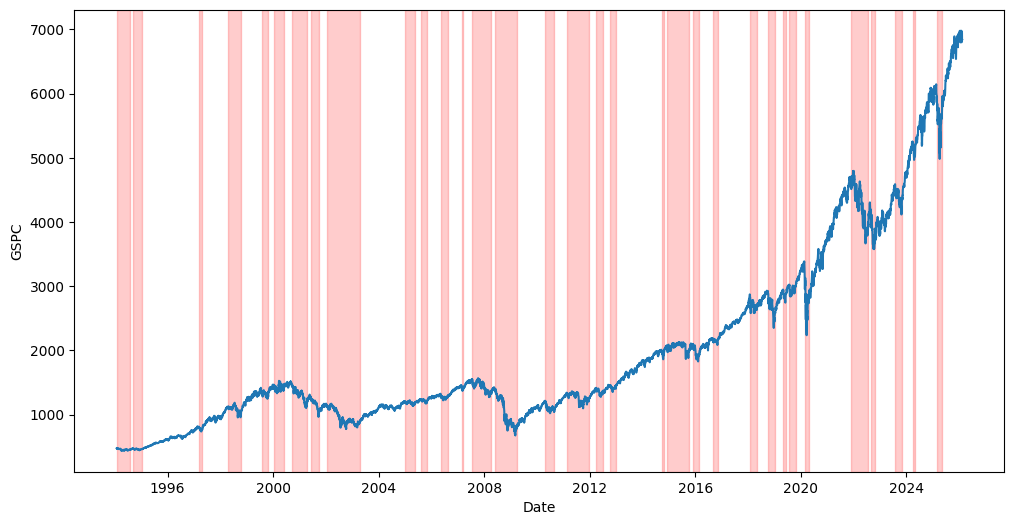

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='GSPC', data=data)
plt.fill_between(
    data['Date'], 
    0, 1, 
    where=(data['regime'] == 'bear'),             
    color='red',                              
    alpha=0.2,                                
    transform=plt.gca().get_xaxis_transform(), 
    label='Bear Regime'
)

In [7]:
data['regime_binary']= np.where(data['regime']=='bull',1,0)


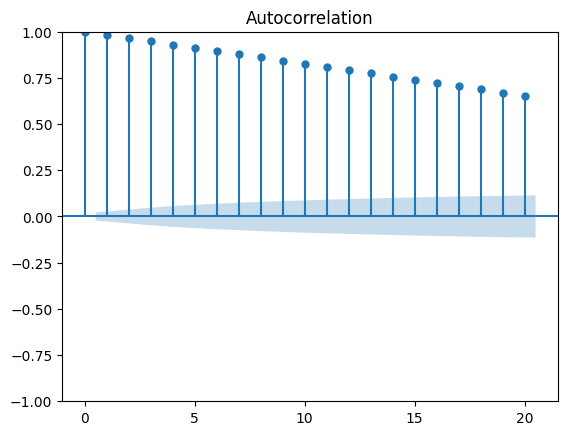

In [8]:

plot_acf(data['regime_binary'], lags=20)
plt.show()

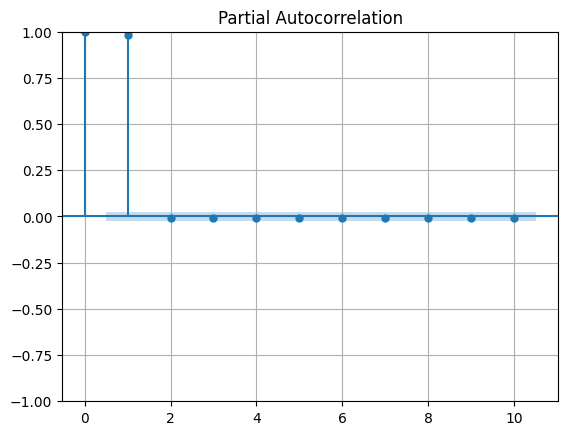

In [9]:

plot_pacf(data['regime_binary'], lags=10)
plt.grid()
plt.show()
### AR(1) model

In [10]:
data['Risk_Adj_Return_20d'] = data['Return_20d'] / (data['VIX'] + 0.00001)

data['SPY_Volume_20d_MA'] = data['SPY Volume'].rolling(window=20).mean()

data['Relative_Volume'] = data['SPY Volume'] / data['SPY_Volume_20d_MA']

data['MACD_Hist_Accel'] = data['MACD_Hist'] - data['MACD_Hist'].shift(1)

data = data.drop(columns=['SPY_Volume_20d_MA']).dropna()

In [11]:
data['lagged_target_1'] = data['regime_binary'].shift(-1)
data['lagged_target_10'] = data['regime_binary'].shift(-10)
data['lagged_target_30'] = data['regime_binary'].shift(-30)

In [12]:
data_1 = data.dropna(subset=['lagged_target_1'])
data_10 = data.dropna(subset=['lagged_target_10']) 
data_30 = data.dropna(subset=['lagged_target_30'])     

In [13]:
stationary_features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 
    'RSI_14', 'MACD_Hist', 'Drawdown', 
    'VIX', 'VIX_Change', 'VIX_Change_5d', 
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    'Risk_Adj_Return_20d','Relative_Volume',
    'MACD_Hist_Accel'
]

In [14]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def station_test(df):
    for col in df.columns:
        res = adfuller(df[col].dropna())
        print('p_value =', np.round(res[1], 5), 'for', col)

station_test(data[stationary_features])


p_value = 0.0 for Return
p_value = 0.0 for Return_5d
p_value = 0.0 for Return_20d
p_value = 0.0 for Return_Smooth
p_value = 0.0 for RSI_14
p_value = 0.0 for MACD_Hist
p_value = 0.12044 for Drawdown
p_value = 0.0 for VIX
p_value = 0.0 for VIX_Change
p_value = 0.0 for VIX_Change_5d
p_value = 8e-05 for GDP_YoY
p_value = 0.29915 for Core_Inflation_YoY
p_value = 0.00489 for M2_YoY
p_value = 0.01537 for Unemployment
p_value = 0.0 for Risk_Adj_Return_20d
p_value = 0.0 for Relative_Volume
p_value = 0.0 for MACD_Hist_Accel


<Axes: xlabel='Date', ylabel='Core_Inflation_YoY'>

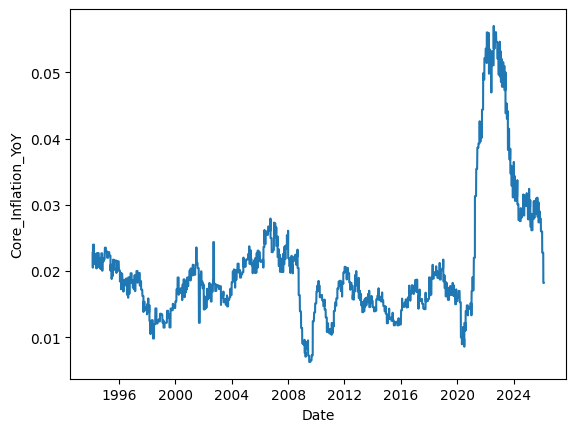

In [15]:
sns.lineplot(x='Date', y='Core_Inflation_YoY', data=data)


<Axes: xlabel='Date', ylabel='Drawdown'>

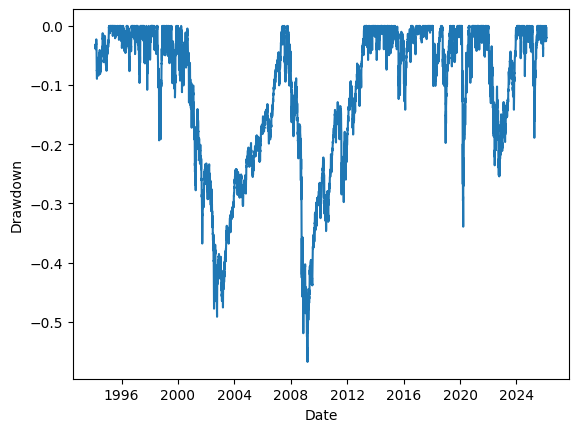

In [16]:
sns.lineplot(x='Date', y='Drawdown', data=data)

In [17]:
X = data_1[stationary_features]
y = data_1['regime_binary']

<Axes: >

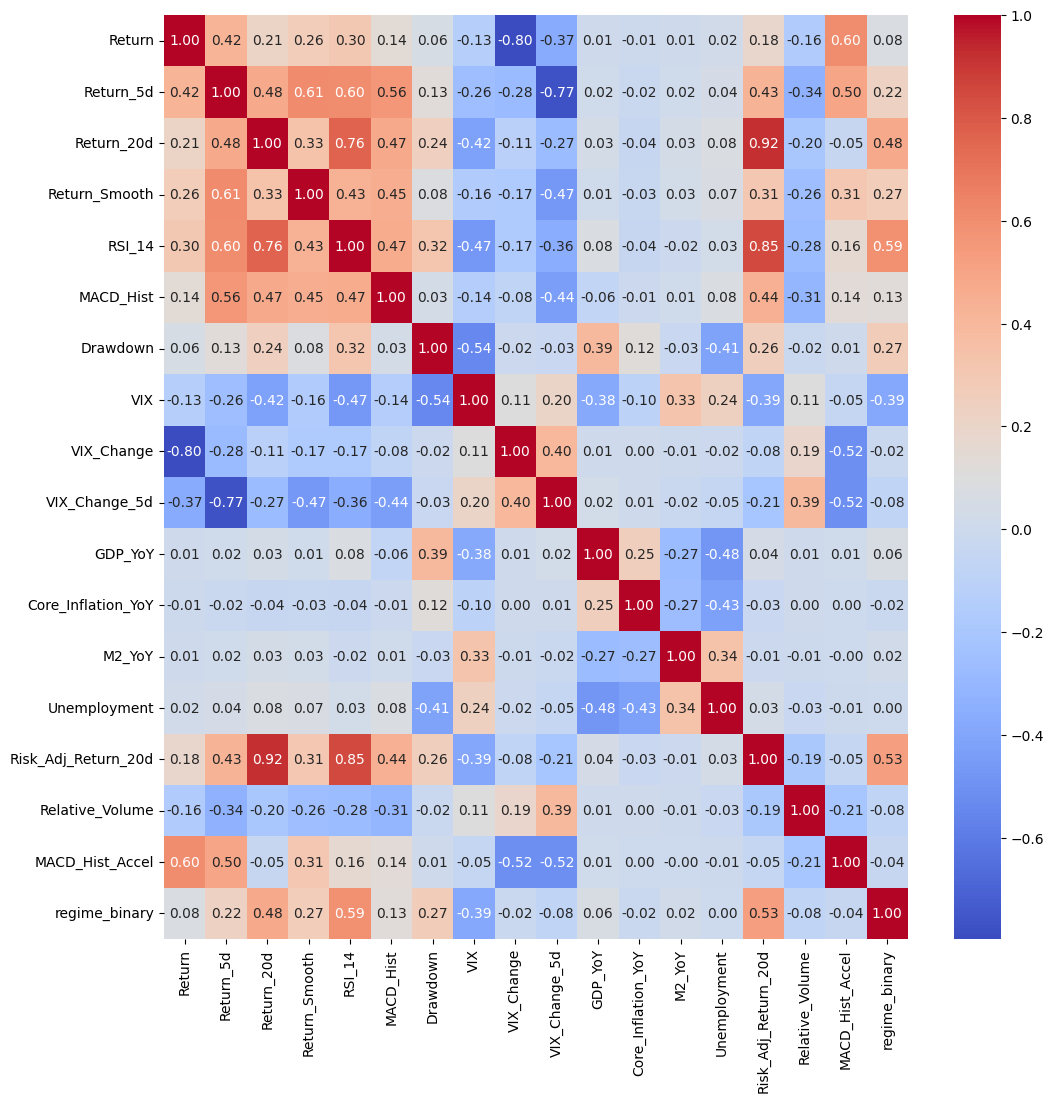

In [18]:
plt.figure(figsize=(12, 12))
cov_matrix = data_1[stationary_features + ['regime_binary']].corr()
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap='coolwarm')

In [19]:
total_rows = len(data_1)

train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85) 


scaler = preprocessing.StandardScaler()

X_train = X.iloc[:train_end]
X_train = scaler.fit_transform(X_train)
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
X_val = scaler.transform(X_val)
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
X_test = scaler.transform(X_test)
y_test = y.iloc[val_end:]

In [20]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, confusion_matrix, roc_curve

# Set up time series cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# We'll use the combined train+val data (85% of data)
# Keep test set (15%) completely separate
X_cv = X.iloc[:len(X) - len(X_test)]  # All data except test set
y_cv = y.iloc[:len(y) - len(y_test)]

In [21]:
cv_results = {
    'fold': [],
    'accuracy': [],
    'roc_auc': [],
    'precision': [],
    'recall': [],
    'best_threshold': []
}

In [22]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    
    # Step A: Extract train/val data for this fold
    X_train_fold = X_cv.iloc[train_idx]
    X_val_fold = X_cv.iloc[val_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_val_fold = y_cv.iloc[val_idx]
    
    # Step B: Fit scaler on TRAINING data only
    scaler_fold = preprocessing.StandardScaler()
    X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold)
    
    # Transform validation data
    X_val_fold_scaled = scaler_fold.transform(X_val_fold)
    
    # Train logistic regression on scaled training data
    logit_fold = sm.Logit(y_train_fold, sm.add_constant(X_train_fold_scaled))
    result_fold = logit_fold.fit(disp=0)
    
    # Make predictions on validation data
    # y_pred_prob = ?
    y_pred_prob = result_fold.predict(sm.add_constant(X_val_fold_scaled))
    # Find best threshold using Youden's J
    fpr, tpr, thresholds = roc_curve(y_val_fold, y_pred_prob)
    j_scores = tpr - fpr 
    best_threshold = thresholds[np.argmax(j_scores)]
    print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
    
    # Calculate metrics and store in cv_results
    # Make binary predictions using threshold
    y_pred = (y_pred_prob >= best_threshold).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(y_val_fold, y_pred)
    roc_auc = roc_auc_score(y_val_fold, y_pred_prob)
    prec = precision_score(y_val_fold, y_pred)
    rec = recall_score(y_val_fold, y_pred)
    
    # Store in cv_results
    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(acc)
    cv_results['roc_auc'].append(roc_auc)
    cv_results['precision'].append(prec)
    cv_results['recall'].append(rec)
    cv_results['best_threshold'].append(best_threshold)
    
    print(f"Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")
    
print("\nCV Complete!")


--- Fold 1/5 ---
Best Threshold (Youden's J): 0.5013
Accuracy: 0.8016, ROC-AUC: 0.8207, Precision: 0.7758, Recall: 0.6841

--- Fold 2/5 ---
Best Threshold (Youden's J): 0.0238
Accuracy: 0.5004, ROC-AUC: 0.5496, Precision: 0.7889, Recall: 0.4405

--- Fold 3/5 ---
Best Threshold (Youden's J): 0.4477
Accuracy: 0.7498, ROC-AUC: 0.8549, Precision: 0.6547, Recall: 0.9100

--- Fold 4/5 ---
Best Threshold (Youden's J): 0.8508
Accuracy: 0.7261, ROC-AUC: 0.8401, Precision: 0.8820, Recall: 0.6542

--- Fold 5/5 ---
Best Threshold (Youden's J): 0.7503
Accuracy: 0.7919, ROC-AUC: 0.8454, Precision: 0.9253, Recall: 0.7891

CV Complete!


In [23]:
# Create summary DataFrame
cv_summary = pd.DataFrame(cv_results)
print("\n=== CV Summary ===")
print(cv_summary)
print(f"\nMean Accuracy: {cv_summary['accuracy'].mean():.4f} (+/- {cv_summary['accuracy'].std():.4f})")
print(f"Mean ROC-AUC: {cv_summary['roc_auc'].mean():.4f} (+/- {cv_summary['roc_auc'].std():.4f})")


=== CV Summary ===
   fold  accuracy   roc_auc  precision    recall  best_threshold
0     1  0.801580  0.820737   0.775773  0.684091        0.501328
1     2  0.500439  0.549550   0.788913  0.440476        0.023785
2     3  0.749781  0.854876   0.654676  0.910000        0.447742
3     4  0.726076  0.840079   0.882022  0.654167        0.850804
4     5  0.791923  0.845425   0.925272  0.789108        0.750254

Mean Accuracy: 0.7140 (+/- 0.1233)
Mean ROC-AUC: 0.7821 (+/- 0.1306)


In [ ]:
# Retraining the logistic regression
scaler_final = preprocessing.StandardScaler()
X_cv_scaled = scaler_final.fit_transform(X_cv)

logit_final = sm.Logit(y_cv, sm.add_constant(X_cv_scaled))
result_final = logit_final.fit(disp=0)

In [31]:
print(result_final.summary())

                           Logit Regression Results                           
Dep. Variable:          regime_binary   No. Observations:                 6839
Model:                          Logit   Df Residuals:                     6821
Method:                           MLE   Df Model:                           17
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.4317
Time:                        16:03:17   Log-Likelihood:                -2593.7
converged:                       True   LL-Null:                       -4563.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7326      0.039     18.580      0.000       0.655       0.810
x1            -0.1574      0.077     -2.037      0.042      -0.309      -0.006
x2            -0.5624      0.089     -6.332      0.0

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'const'),
  Text(1, 0, 'Return'),
  Text(2, 0, 'Return_5d'),
  Text(3, 0, 'Return_20d'),
  Text(4, 0, 'Return_Smooth'),
  Text(5, 0, 'RSI_14'),
  Text(6, 0, 'MACD_Hist'),
  Text(7, 0, 'Drawdown'),
  Text(8, 0, 'VIX'),
  Text(9, 0, 'VIX_Change'),
  Text(10, 0, 'VIX_Change_5d'),
  Text(11, 0, 'GDP_YoY'),
  Text(12, 0, 'Core_Inflation_YoY'),
  Text(13, 0, 'M2_YoY'),
  Text(14, 0, 'Unemployment'),
  Text(15, 0, 'Risk_Adj_Return_20d'),
  Text(16, 0, 'Relative_Volume'),
  Text(17, 0, 'MACD_Hist_Accel')])

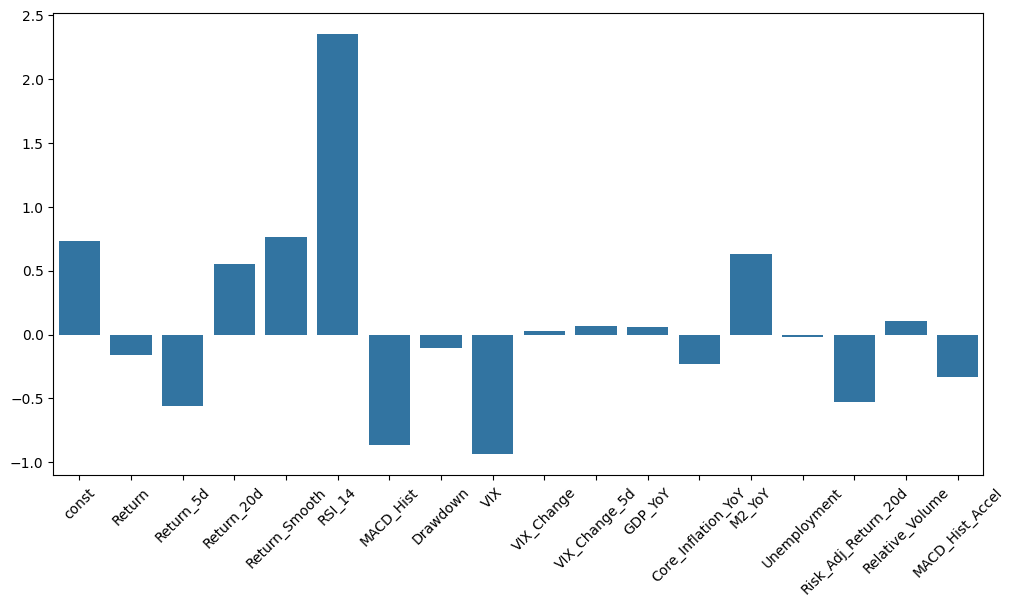

In [32]:
plt.figure(figsize=(12, 6))
names = ['const'] + list(X.columns)
sns.barplot(x=names, y=result_final.params.values)
plt.xticks(rotation=45)

In [25]:
# Evaluting on Held-Out Test Set
# Predictions on test set
y_pred_prob_test = result_final.predict(sm.add_constant(X_test))

# Find threshold (or reuse the CV average threshold)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
j_scores = tpr - fpr
best_threshold_test = thresholds[np.argmax(j_scores)]
print(best_threshold_test)

# Binary predictions
y_pred_test = (y_pred_prob_test >= best_threshold_test).astype(int)

0.345727650725077


In [26]:
print(f"Total trading days: {total_rows}")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Total trading days: 8046
Training shapes: X=(5632, 17), y=(5632,)
Validation shapes: X=(1207, 17), y=(1207,)
Test shapes: X=(1207, 17), y=(1207,)


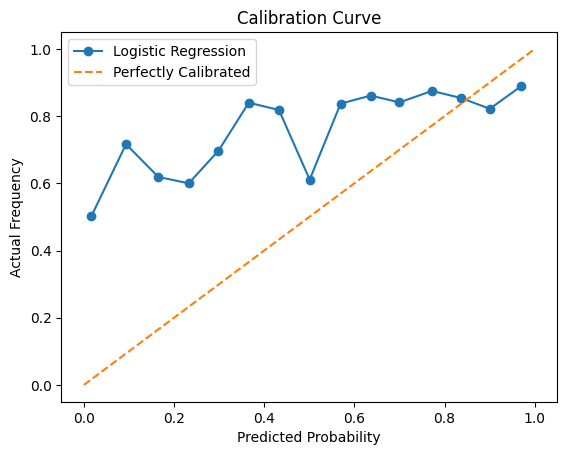

In [27]:
# Calibration curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob_test, n_bins=15)

plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Frequency')
plt.title('Calibration Curve')
plt.legend()
plt.show()

<Axes: >

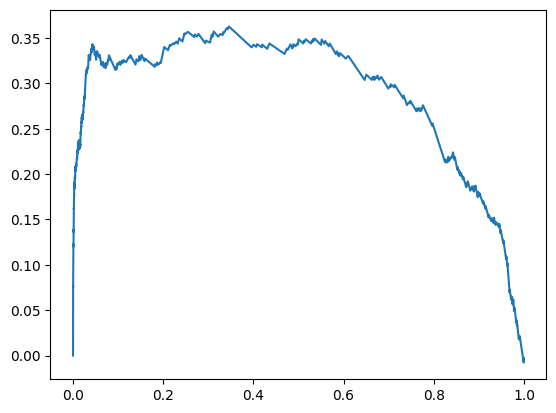

In [28]:
# ROC curve 
sns.lineplot(x=thresholds, y=j_scores)

<Axes: xlabel='col_0', ylabel='regime_binary'>

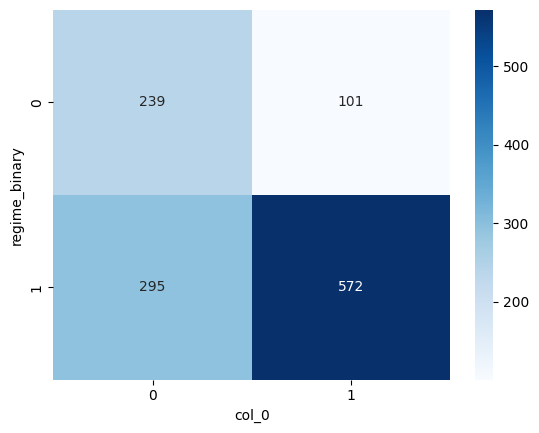

In [29]:
# Confusion matrix
sns.heatmap(pd.crosstab(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues')

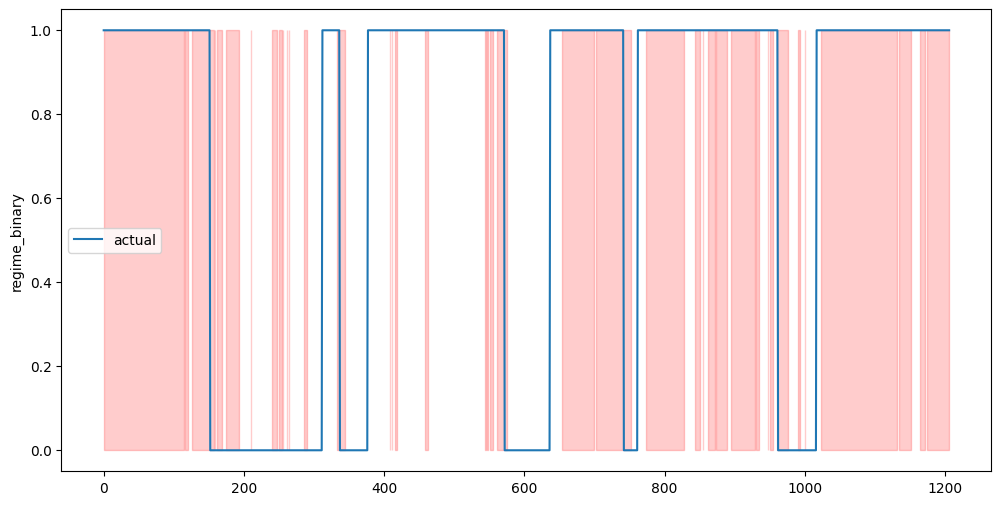

In [30]:
# Prediction timeline plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_test)), y=y_test, label='actual')
plt.fill_between(range(len(X_test)), 0, 1, where=(y_pred_test == 1), 
                 color='red', alpha=0.2, label='predicted')

In [34]:
model =  XGBClassifier(n_estimators=150, random_state=0,max_depth=5, learning_rate=0.1)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10  
)

[0]	validation_0-logloss:0.62304	validation_1-logloss:0.58582
[10]	validation_0-logloss:0.35830	validation_1-logloss:0.41840
[20]	validation_0-logloss:0.25281	validation_1-logloss:0.36749
[30]	validation_0-logloss:0.19251	validation_1-logloss:0.34488
[40]	validation_0-logloss:0.14915	validation_1-logloss:0.33915
[50]	validation_0-logloss:0.11716	validation_1-logloss:0.32750
[60]	validation_0-logloss:0.09623	validation_1-logloss:0.30970
[70]	validation_0-logloss:0.07712	validation_1-logloss:0.30282
[80]	validation_0-logloss:0.06599	validation_1-logloss:0.29593
[90]	validation_0-logloss:0.05661	validation_1-logloss:0.28886
[100]	validation_0-logloss:0.04805	validation_1-logloss:0.28905
[110]	validation_0-logloss:0.04154	validation_1-logloss:0.28491
[120]	validation_0-logloss:0.03620	validation_1-logloss:0.28322
[130]	validation_0-logloss:0.03154	validation_1-logloss:0.28748
[140]	validation_0-logloss:0.02761	validation_1-logloss:0.28861
[149]	validation_0-logloss:0.02510	validation_1-log

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
results = model.evals_result()

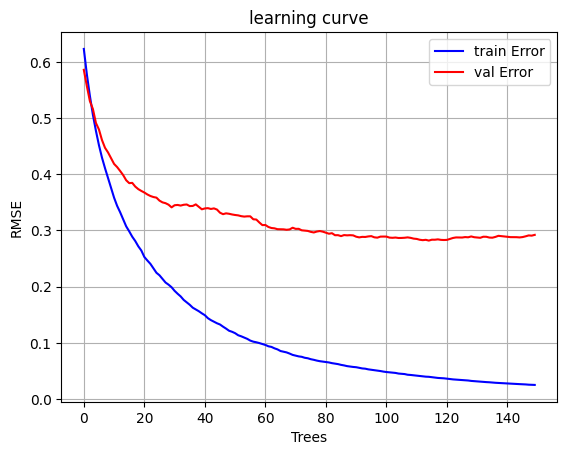

In [36]:
results = model.evals_result()
train_rmse = results['validation_0']['logloss']
val_rmse = results['validation_1']['logloss']

plt.plot(train_rmse, label='train Error', color='blue')
plt.plot(val_rmse, label='val Error', color='red')
plt.title('learning curve')
plt.xlabel('Trees')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

<Axes: >

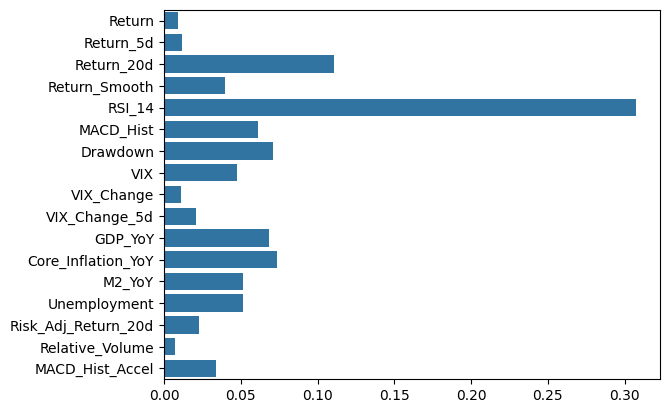

In [37]:
sns.barplot(x=model.feature_importances_, y=names[1:])

array([0.9475684 , 0.98199975, 0.974621  , ..., 0.99197996, 0.98823255,
       0.9975961 ], dtype=float32)

Best Threshold (Youden's J): 0.9198


<Axes: >

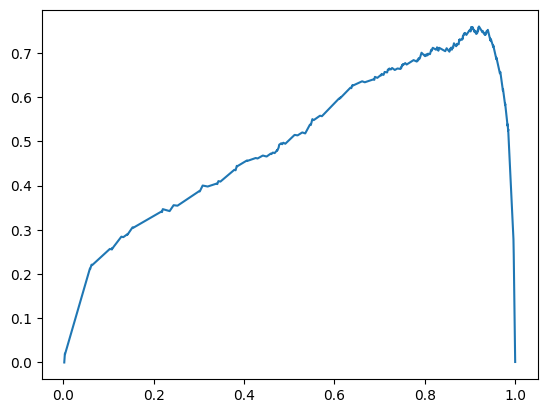

In [38]:
y_pred_prob_val = model.predict_proba(X_val)[:, 1].flatten()


fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob_val)
# J = TPR – FPR
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
sns.lineplot(x=thresholds, y=j_scores)

In [39]:
# y_pred_val = model.predict(X_val)
best_threshold = 0.838
y_pred_val = (y_pred_prob_val >= best_threshold).astype(int)

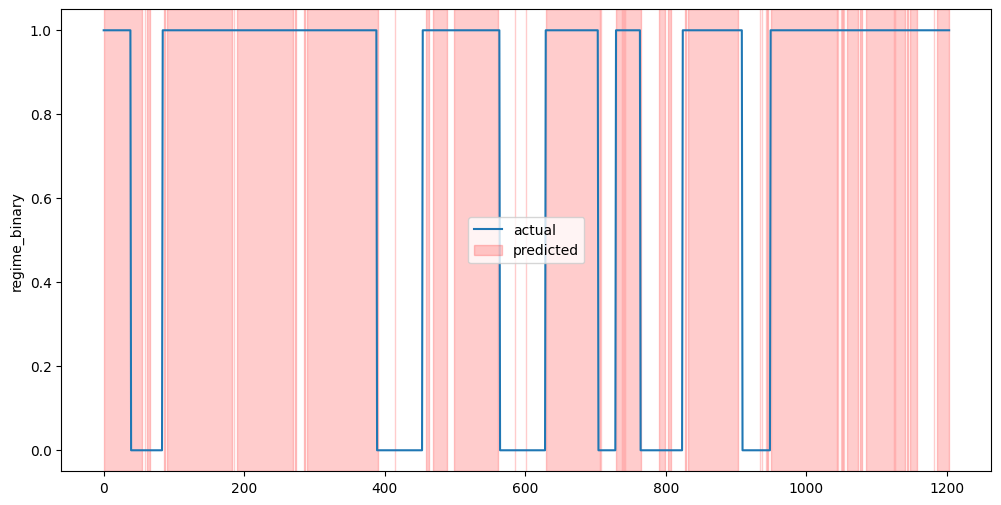

In [40]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

<Axes: xlabel='col_0', ylabel='regime_binary'>

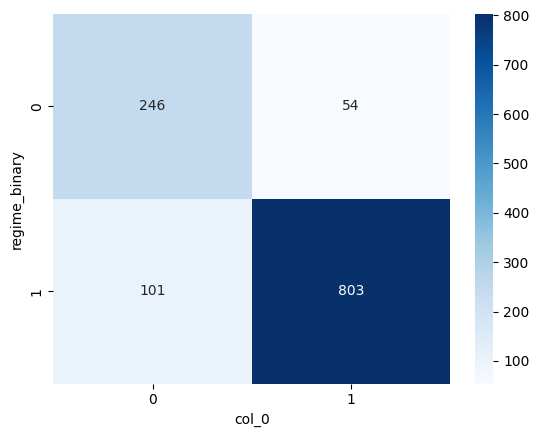

In [41]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='col_0', ylabel='regime_binary'>

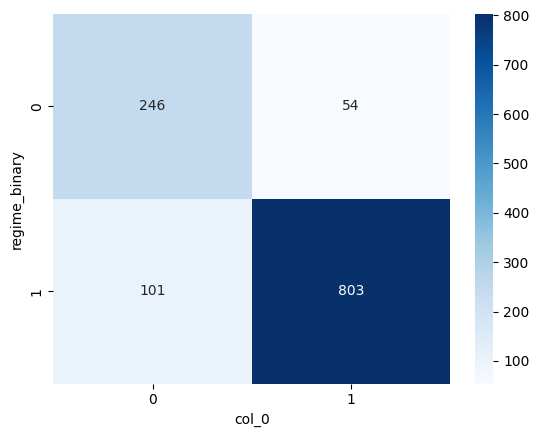

In [42]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

In [43]:
import shap
explainer = shap.TreeExplainer(model)

shap_values = explainer(pd.DataFrame(X_val, columns=names[1:]))

/Users/sid/Documents/COMP0047 Data Science/COMP0047-Data-Science-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


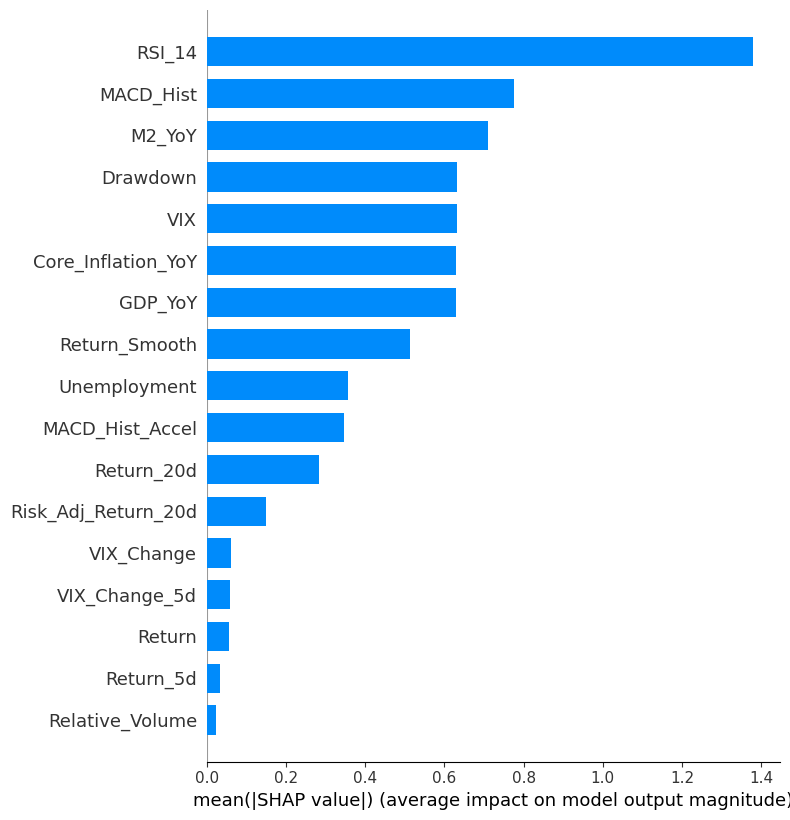

In [44]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, feature_names=names[1:], plot_type='bar')

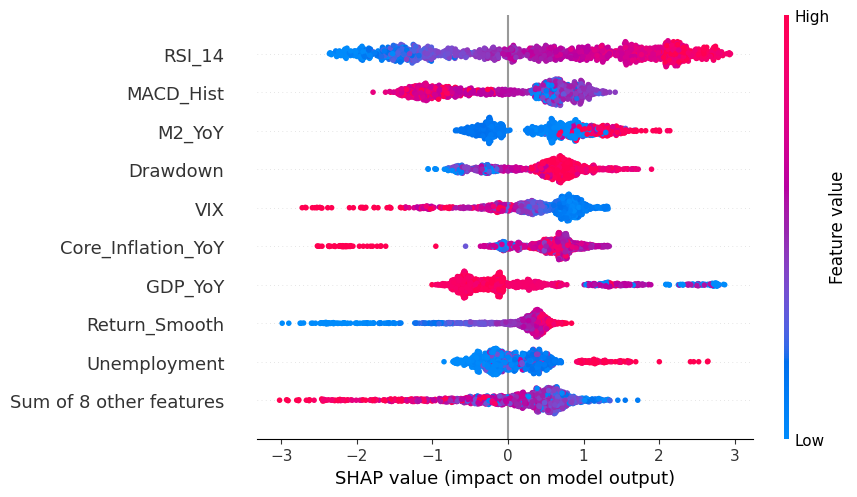

In [45]:
shap.plots.beeswarm(shap_values)
